### Subject Visualizations

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import random

from src.config import PROCESSED_DATA_DIR

2026-05-21 21:18:13.951 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/virginia/Desktop/GitHub/cycle-tracking/cycle-tracking


In [2]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "features_interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "features_intraday.csv", parse_dates=["datetime"])

In [3]:
print(f"All cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")
interday = interday[interday["is_complete_cycle"]].copy()
complete_pairs = interday[["id", "cycle_id"]].drop_duplicates()
intraday = intraday.merge(complete_pairs, on=["id", "cycle_id"])
print(f"Complete cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")

subject_ids = sorted(random.sample(list(interday["id"].unique()), 30))

All cycles: 126  |  subjects: 38
Complete cycles: 88  |  subjects: 37


In [4]:
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
PHASE_COLORS = {
    "Menstrual": "#ca0020",
    "Follicular": "#ef8a62",
    "Fertility": "#67a9cf",
    "Luteal": "#0571b0",
}
REPORT_COLS = [
    "appetite", "exerciselevel", "headaches", "cramps", "sorebreasts",
    "fatigue", "sleepissue", "moodswing", "stress", "foodcravings",
    "indigestion", "bloating",
]

### Hormone changes

[<matplotlib.lines.Line2D object at 0x126d48ad0>] [<matplotlib.lines.Line2D object at 0x126d48c20>]


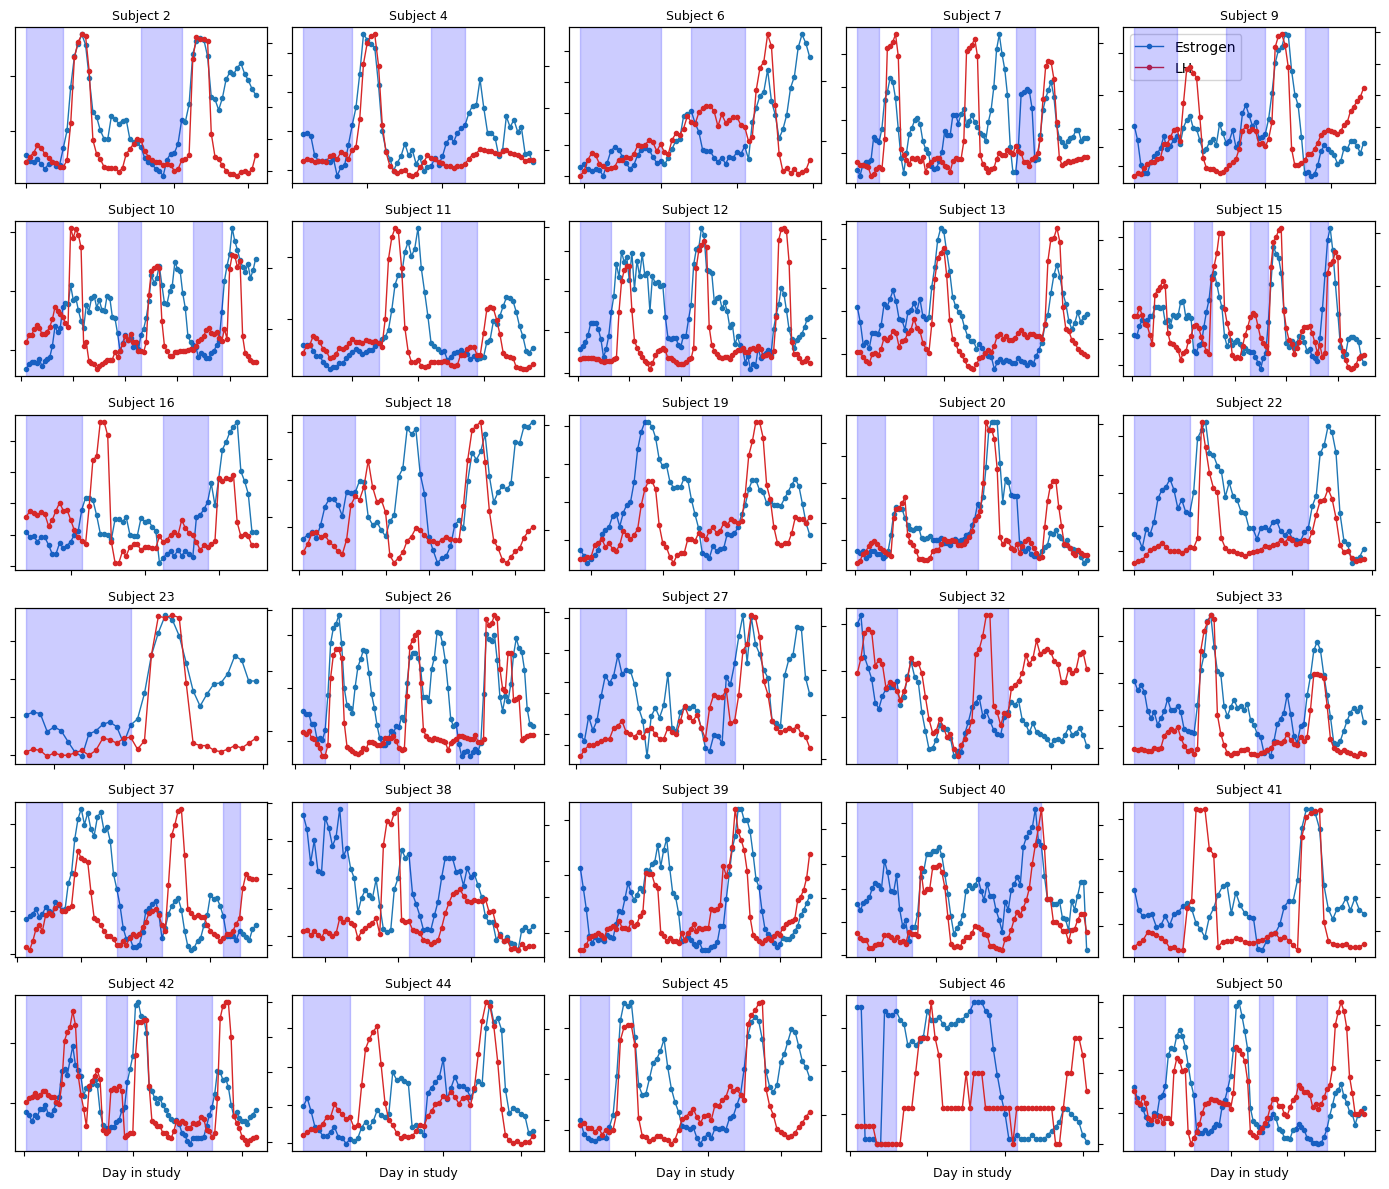

In [12]:
fig, axes = plt.subplots(6, 5, figsize=(14, 12))
axes = axes.flatten()

for i, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    ax = axes[i]
    ax2 = ax.twinx()
    row, col = divmod(i, 5)
    ax.plot(grp["day_in_study"], grp["estrogen_smooth"], 
            marker="o", markersize=3, color="tab:blue", linewidth=1, label="Estrogen")
    ax2.plot(grp["day_in_study"], grp["lh_smooth"], 
             marker="o", markersize=3, color="tab:red", linewidth=1, label="LH")
    ax.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"Subject {sid}", fontsize=9)
    if row == 5:
        ax.set_xlabel("Day in study", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if row == 0 and col == 4:
        print(lines1, lines2)
        ax.legend(lines1 + lines2, labels1 + labels2)

    mask = grp["phase_dual"] == "Follicular"
    changes = mask.ne(mask.shift()).cumsum()
    for j, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
        plt.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                    label="Follicular" if j == 0 else "_nolegend_")

fig.tight_layout()
plt.show()

### Temperature changes

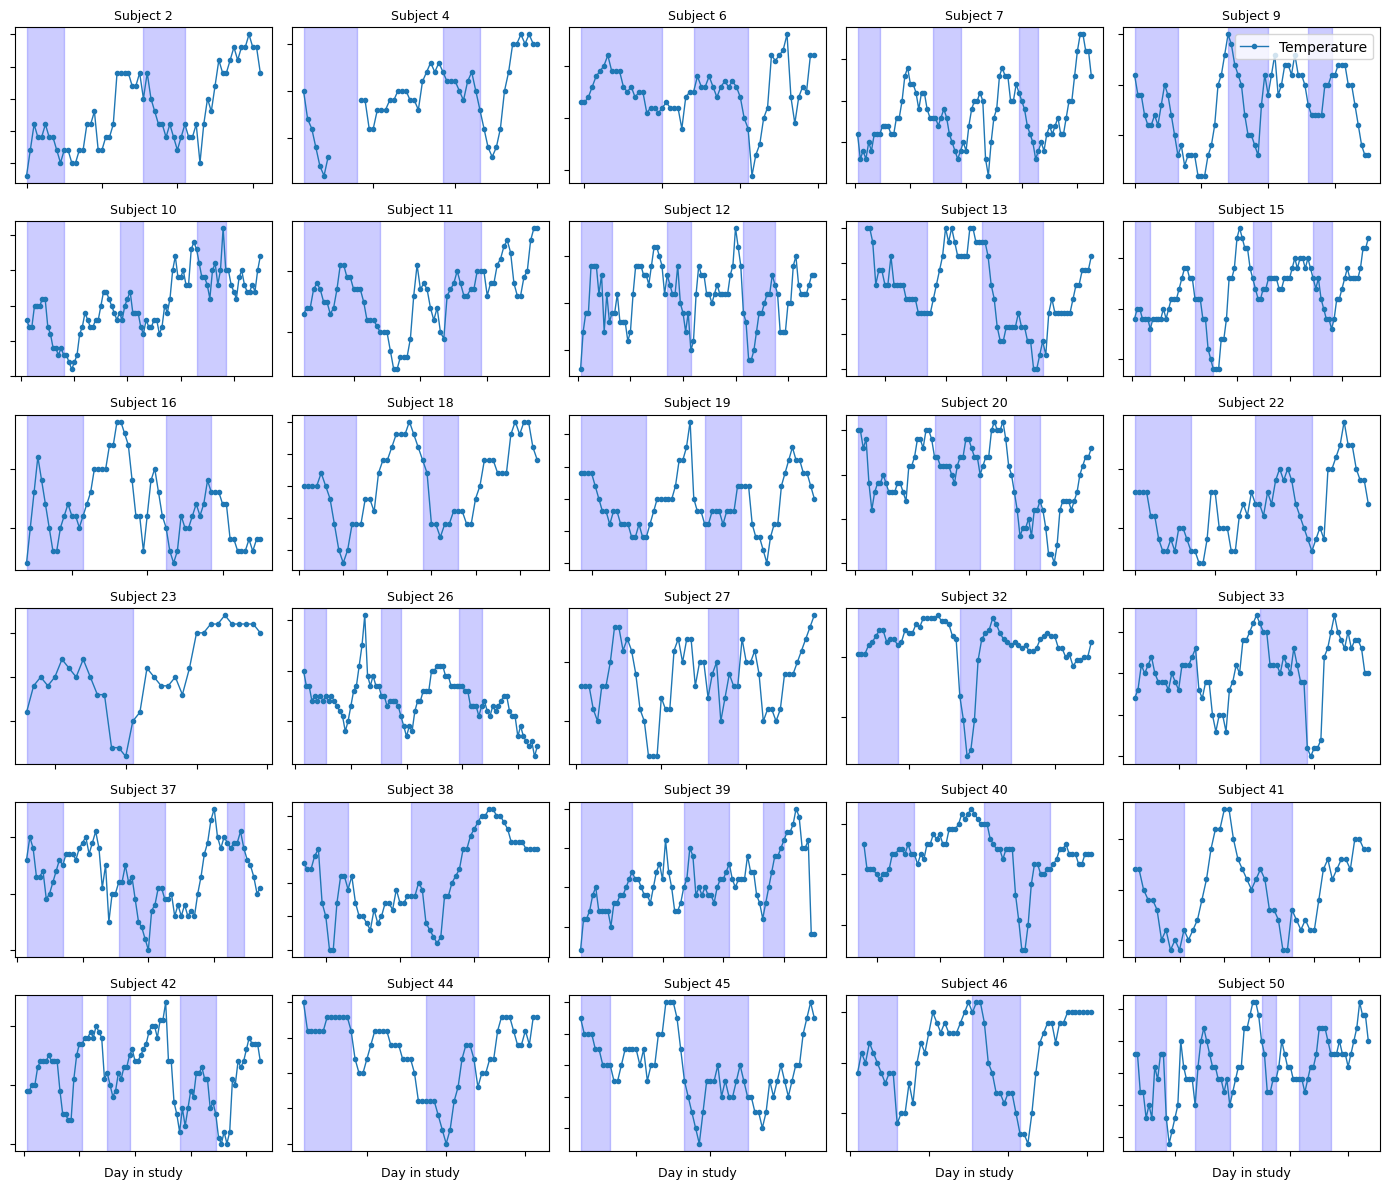

In [17]:
fig, axes = plt.subplots(6, 5, figsize=(14, 12))
axes = axes.flatten()

for i, sid in enumerate(subject_ids):
    grp = interday[interday["id"] == sid].sort_values("day_in_study")
    grp["temperature_smooth"] = grp["temperature"].transform(lambda x: x.rolling(window=5, center=True, min_periods=1).mean()).round(1)
    ax = axes[i]
    row, col = divmod(i, 5)
    ax.plot(grp["day_in_study"], grp["temperature_smooth"], 
            marker="o", markersize=3, color="tab:blue", linewidth=1, label="Temperature")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"Subject {sid}", fontsize=9)
    if row == 5:
        ax.set_xlabel("Day in study", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    if row == 0 and col == 4:
        ax.legend(lines1, labels1)

    mask = grp["phase_dual"] == "Follicular"
    changes = mask.ne(mask.shift()).cumsum()
    for j, (_, segment) in enumerate(grp[mask].groupby(changes[mask])):
        ax.axvspan(segment["day_in_study"].min(), segment["day_in_study"].max(), alpha=0.2, color="blue",
                    label="Follicular" if j == 0 else "_nolegend_")

fig.tight_layout()
plt.show()